In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from iertools.read import read_sql
from dateutil.parser import parse

In [63]:
f = "../osm/013_modificacion/run/eplusout.sql"
cb = read_sql(f,alias=True)
data_cb = cb.data
data_cb

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,To,RECAMARAPA:Zone Air Relative Humidity (%),RECAMARAPA:Zone Air Temperature (C),Ti_RECAMARAPA,RECAMARAPB:Zone Air Relative Humidity (%),RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,15.875336,NaN,NaN,18.341211,NaN,NaN,20.391096,NaN,...,8.566667,NaN,NaN,15.028296,NaN,NaN,15.060757,NaN,NaN,17.498457
2006-01-01 00:20:00,NaN,NaN,15.834611,NaN,NaN,18.265357,NaN,NaN,20.303718,NaN,...,8.333333,NaN,NaN,14.926259,NaN,NaN,14.997618,NaN,NaN,17.392559
2006-01-01 00:30:00,NaN,NaN,15.792917,NaN,NaN,18.191310,NaN,NaN,20.215694,NaN,...,8.100000,NaN,NaN,14.822109,NaN,NaN,14.932578,NaN,NaN,17.286770
2006-01-01 00:40:00,NaN,NaN,15.749197,NaN,NaN,18.119315,NaN,NaN,20.125153,NaN,...,7.866667,NaN,NaN,14.720761,NaN,NaN,14.863191,NaN,NaN,17.179488
2006-01-01 00:50:00,NaN,NaN,15.702778,NaN,NaN,18.047369,NaN,NaN,20.034640,NaN,...,7.633333,NaN,NaN,14.621861,NaN,NaN,14.788735,NaN,NaN,17.071413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,15.600781,NaN,NaN,17.975080,NaN,NaN,20.117233,NaN,...,10.366667,NaN,NaN,15.115093,NaN,NaN,14.895479,NaN,NaN,17.493418
2006-12-31 23:30:00,NaN,NaN,15.575942,NaN,NaN,17.924359,NaN,NaN,20.040253,NaN,...,10.300000,NaN,NaN,15.041948,NaN,NaN,14.855624,NaN,NaN,17.410702
2006-12-31 23:40:00,NaN,NaN,15.549530,NaN,NaN,17.872016,NaN,NaN,19.963115,NaN,...,10.233333,NaN,NaN,14.967537,NaN,NaN,14.814164,NaN,NaN,17.326870


(np.float64(13269.0), np.float64(13300.0))

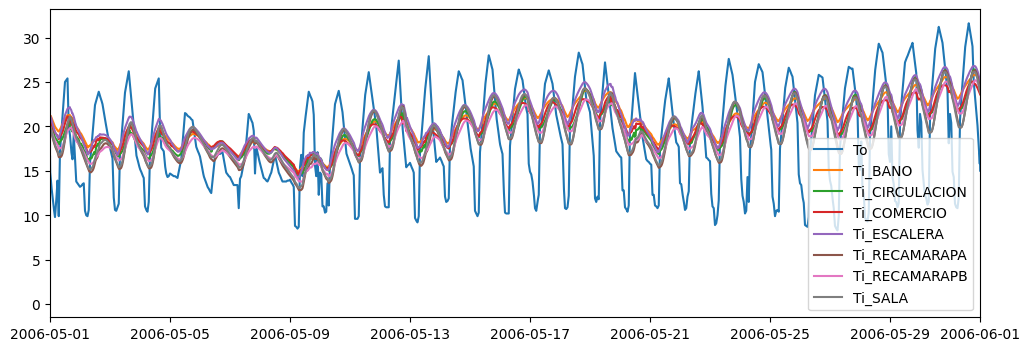

In [64]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-05-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(data_cb.To, label="To")
ax.plot(data_cb.Ti_BANO, label="Ti_BANO")
ax.plot(data_cb.Ti_CIRCULACION, label="Ti_CIRCULACION")
ax.plot(data_cb.Ti_COMERCIO, label="Ti_COMERCIO")
ax.plot(data_cb.Ti_ESCALERA, label="Ti_ESCALERA")
ax.plot(data_cb.Ti_RECAMARAPA, label="Ti_RECAMARAPA")
ax.plot(data_cb.Ti_RECAMARAPB, label="Ti_RECAMARAPB")
ax.plot(data_cb.Ti_SALA, label="Ti_SALA")

ax.legend()

ax.set_xlim(f1,f2)

In [65]:
a = {"bano":1.7*2.2}

In [66]:
areas = {"BANO":1.7*2.2, "CIRCULACION":3.7, "COMERCIO":3.4*3+1.2*0.7, "ESCALERA":2.2*2.7, "RECAMARAPA":2.6*4.4+1.7*2.2, "RECAMARAPB":2.6*4.4, "SALA":4.4*3.7}

In [67]:
pesos = {nombre: area / sum(areas.values()) for nombre, area in areas.items()}
pesos

{'BANO': 0.05555555555555555,
 'CIRCULACION': 0.054961378490790254,
 'COMERCIO': 0.1639928698752228,
 'ESCALERA': 0.08823529411764706,
 'RECAMARAPA': 0.22549019607843138,
 'RECAMARAPB': 0.16993464052287582,
 'SALA': 0.24183006535947713}

In [68]:
temps = data_cb.copy()
temps["Ti_CB"] = sum(temps[f"Ti_{zona}"] * peso for zona, peso in pesos.items())
temps

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,RECAMARAPA:Zone Air Relative Humidity (%),RECAMARAPA:Zone Air Temperature (C),Ti_RECAMARAPA,RECAMARAPB:Zone Air Relative Humidity (%),RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA,Ti_CB
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,15.875336,NaN,NaN,18.341211,NaN,NaN,20.391096,NaN,...,NaN,NaN,15.028296,NaN,NaN,15.060757,NaN,NaN,17.498457,16.866821
2006-01-01 00:20:00,NaN,NaN,15.834611,NaN,NaN,18.265357,NaN,NaN,20.303718,NaN,...,NaN,NaN,14.926259,NaN,NaN,14.997618,NaN,NaN,17.392559,16.781090
2006-01-01 00:30:00,NaN,NaN,15.792917,NaN,NaN,18.191310,NaN,NaN,20.215694,NaN,...,NaN,NaN,14.822109,NaN,NaN,14.932578,NaN,NaN,17.286770,16.694578
2006-01-01 00:40:00,NaN,NaN,15.749197,NaN,NaN,18.119315,NaN,NaN,20.125153,NaN,...,NaN,NaN,14.720761,NaN,NaN,14.863191,NaN,NaN,17.179488,16.607128
2006-01-01 00:50:00,NaN,NaN,15.702778,NaN,NaN,18.047369,NaN,NaN,20.034640,NaN,...,NaN,NaN,14.621861,NaN,NaN,14.788735,NaN,NaN,17.071413,16.518970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,15.600781,NaN,NaN,17.975080,NaN,NaN,20.117233,NaN,...,NaN,NaN,15.115093,NaN,NaN,14.895479,NaN,NaN,17.493418,16.763921
2006-12-31 23:30:00,NaN,NaN,15.575942,NaN,NaN,17.924359,NaN,NaN,20.040253,NaN,...,NaN,NaN,15.041948,NaN,NaN,14.855624,NaN,NaN,17.410702,16.700208
2006-12-31 23:40:00,NaN,NaN,15.549530,NaN,NaN,17.872016,NaN,NaN,19.963115,NaN,...,NaN,NaN,14.967537,NaN,NaN,14.814164,NaN,NaN,17.326870,16.635332


(np.float64(13269.0), np.float64(13300.0))

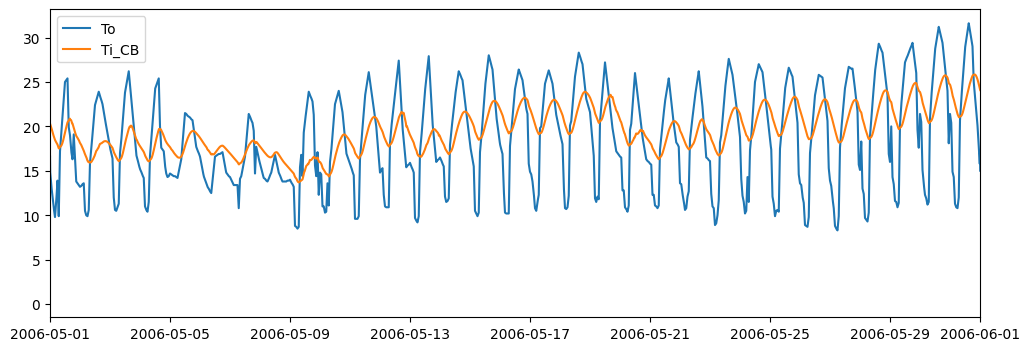

In [69]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-05-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(temps.To, label="To")
ax.plot(temps.Ti_CB, label="Ti_CB")

ax.legend()

ax.set_xlim(f1,f2)

In [70]:
f = "../osm/014_a0p25/run/eplusout.sql"
a0p25 = read_sql(f,alias=True)
data_a0p25 = a0p25.data
data_a0p25

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,To,RECAMARAPA:Zone Air Relative Humidity (%),RECAMARAPA:Zone Air Temperature (C),Ti_RECAMARAPA,RECAMARAPB:Zone Air Relative Humidity (%),RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,14.069171,NaN,NaN,16.239915,NaN,NaN,18.302618,NaN,...,8.566667,NaN,NaN,12.789706,NaN,NaN,13.365523,NaN,NaN,14.955040
2006-01-01 00:20:00,NaN,NaN,14.035640,NaN,NaN,16.176996,NaN,NaN,18.223876,NaN,...,8.333333,NaN,NaN,12.708076,NaN,NaN,13.315890,NaN,NaN,14.869728
2006-01-01 00:30:00,NaN,NaN,14.001357,NaN,NaN,16.114859,NaN,NaN,18.143174,NaN,...,8.100000,NaN,NaN,12.628372,NaN,NaN,13.265924,NaN,NaN,14.783986
2006-01-01 00:40:00,NaN,NaN,13.965528,NaN,NaN,16.053658,NaN,NaN,18.059531,NaN,...,7.866667,NaN,NaN,12.549802,NaN,NaN,13.214051,NaN,NaN,14.696681
2006-01-01 00:50:00,NaN,NaN,13.928434,NaN,NaN,15.992295,NaN,NaN,17.975000,NaN,...,7.633333,NaN,NaN,12.471092,NaN,NaN,13.159910,NaN,NaN,14.608359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,14.076039,NaN,NaN,16.135251,NaN,NaN,18.304886,NaN,...,10.366667,NaN,NaN,13.084120,NaN,NaN,13.411329,NaN,NaN,15.181749
2006-12-31 23:30:00,NaN,NaN,14.056672,NaN,NaN,16.096636,NaN,NaN,18.240979,NaN,...,10.300000,NaN,NaN,13.026970,NaN,NaN,13.382491,NaN,NaN,15.117876
2006-12-31 23:40:00,NaN,NaN,14.035761,NaN,NaN,16.056017,NaN,NaN,18.174897,NaN,...,10.233333,NaN,NaN,12.968337,NaN,NaN,13.352265,NaN,NaN,15.052672


In [71]:
temps["Ti_a0p25"] = sum(data_a0p25[f"Ti_{zona}"] * peso for zona, peso in pesos.items())
temps

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,RECAMARAPA:Zone Air Temperature (C),Ti_RECAMARAPA,RECAMARAPB:Zone Air Relative Humidity (%),RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA,Ti_CB,Ti_a0p25
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,15.875336,NaN,NaN,18.341211,NaN,NaN,20.391096,NaN,...,NaN,15.028296,NaN,NaN,15.060757,NaN,NaN,17.498457,16.866821,14.723733
2006-01-01 00:20:00,NaN,NaN,15.834611,NaN,NaN,18.265357,NaN,NaN,20.303718,NaN,...,NaN,14.926259,NaN,NaN,14.997618,NaN,NaN,17.392559,16.781090,14.653233
2006-01-01 00:30:00,NaN,NaN,15.792917,NaN,NaN,18.191310,NaN,NaN,20.215694,NaN,...,NaN,14.822109,NaN,NaN,14.932578,NaN,NaN,17.286770,16.694578,14.582641
2006-01-01 00:40:00,NaN,NaN,15.749197,NaN,NaN,18.119315,NaN,NaN,20.125153,NaN,...,NaN,14.720761,NaN,NaN,14.863191,NaN,NaN,17.179488,16.607128,14.510939
2006-01-01 00:50:00,NaN,NaN,15.702778,NaN,NaN,18.047369,NaN,NaN,20.034640,NaN,...,NaN,14.621861,NaN,NaN,14.788735,NaN,NaN,17.071413,16.518970,14.438225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,15.600781,NaN,NaN,17.975080,NaN,NaN,20.117233,NaN,...,NaN,15.115093,NaN,NaN,14.895479,NaN,NaN,17.493418,16.763921,14.858670
2006-12-31 23:30:00,NaN,NaN,15.575942,NaN,NaN,17.924359,NaN,NaN,20.040253,NaN,...,NaN,15.041948,NaN,NaN,14.855624,NaN,NaN,17.410702,16.700208,14.808625
2006-12-31 23:40:00,NaN,NaN,15.549530,NaN,NaN,17.872016,NaN,NaN,19.963115,NaN,...,NaN,14.967537,NaN,NaN,14.814164,NaN,NaN,17.326870,16.635332,14.756996


(np.float64(13269.0), np.float64(13300.0))

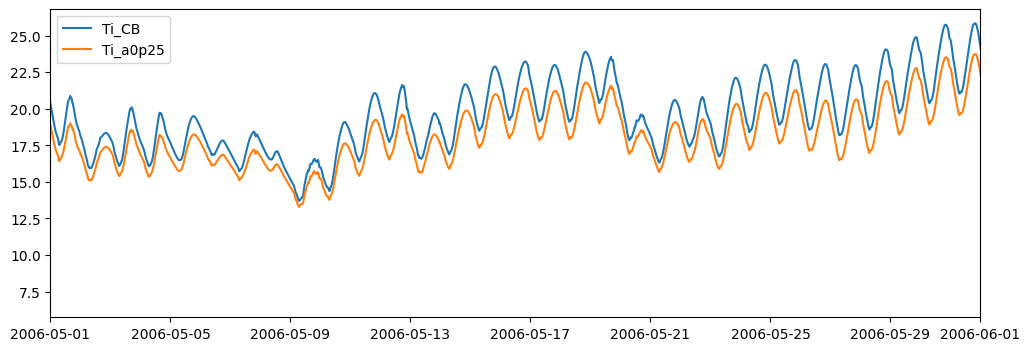

In [72]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-05-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(temps.Ti_CB, label="Ti_CB")
ax.plot(temps.Ti_a0p25, label="Ti_a0p25")

ax.legend()

ax.set_xlim(f1,f2)

In [73]:
f = "../osm/016_adobe/run/eplusout.sql"
adobe = read_sql(f,alias=True)
data_adobe = adobe.data
data_adobe

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,To,RECAMARAPA:Zone Air Relative Humidity (%),RECAMARAPA:Zone Air Temperature (C),Ti_RECAMARAPA,RECAMARAPB:Zone Air Relative Humidity (%),RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,13.972583,NaN,NaN,16.108166,NaN,NaN,18.453436,NaN,...,8.566667,NaN,NaN,12.544660,NaN,NaN,13.139615,NaN,NaN,14.930799
2006-01-01 00:20:00,NaN,NaN,13.951578,NaN,NaN,16.066274,NaN,NaN,18.385855,NaN,...,8.333333,NaN,NaN,12.488172,NaN,NaN,13.112622,NaN,NaN,14.865982
2006-01-01 00:30:00,NaN,NaN,13.929858,NaN,NaN,16.024776,NaN,NaN,18.319531,NaN,...,8.100000,NaN,NaN,12.430244,NaN,NaN,13.085495,NaN,NaN,14.800537
2006-01-01 00:40:00,NaN,NaN,13.906761,NaN,NaN,15.983754,NaN,NaN,18.251408,NaN,...,7.866667,NaN,NaN,12.372337,NaN,NaN,13.056858,NaN,NaN,14.733350
2006-01-01 00:50:00,NaN,NaN,13.882703,NaN,NaN,15.942168,NaN,NaN,18.181614,NaN,...,7.633333,NaN,NaN,12.314894,NaN,NaN,13.026492,NaN,NaN,14.664998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,13.889737,NaN,NaN,15.866801,NaN,NaN,18.310348,NaN,...,10.366667,NaN,NaN,12.878233,NaN,NaN,13.187481,NaN,NaN,15.112066
2006-12-31 23:30:00,NaN,NaN,13.879432,NaN,NaN,15.845366,NaN,NaN,18.258812,NaN,...,10.300000,NaN,NaN,12.838418,NaN,NaN,13.175525,NaN,NaN,15.063745
2006-12-31 23:40:00,NaN,NaN,13.867549,NaN,NaN,15.821536,NaN,NaN,18.205828,NaN,...,10.233333,NaN,NaN,12.797160,NaN,NaN,13.162381,NaN,NaN,15.013986


In [74]:
temps["Ti_adobe"] = sum(data_adobe[f"Ti_{zona}"] * peso for zona, peso in pesos.items())
temps

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,Ti_RECAMARAPA,RECAMARAPB:Zone Air Relative Humidity (%),RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA,Ti_CB,Ti_a0p25,Ti_adobe
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,15.875336,NaN,NaN,18.341211,NaN,NaN,20.391096,NaN,...,15.028296,NaN,NaN,15.060757,NaN,NaN,17.498457,16.866821,14.723733,14.626421
2006-01-01 00:20:00,NaN,NaN,15.834611,NaN,NaN,18.265357,NaN,NaN,20.303718,NaN,...,14.926259,NaN,NaN,14.997618,NaN,NaN,17.392559,16.781090,14.653233,14.575291
2006-01-01 00:30:00,NaN,NaN,15.792917,NaN,NaN,18.191310,NaN,NaN,20.215694,NaN,...,14.822109,NaN,NaN,14.932578,NaN,NaN,17.286770,16.694578,14.582641,14.523813
2006-01-01 00:40:00,NaN,NaN,15.749197,NaN,NaN,18.119315,NaN,NaN,20.125153,NaN,...,14.720761,NaN,NaN,14.863191,NaN,NaN,17.179488,16.607128,14.510939,14.471190
2006-01-01 00:50:00,NaN,NaN,15.702778,NaN,NaN,18.047369,NaN,NaN,20.034640,NaN,...,14.621861,NaN,NaN,14.788735,NaN,NaN,17.071413,16.518970,14.438225,14.417641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,15.600781,NaN,NaN,17.975080,NaN,NaN,20.117233,NaN,...,15.115093,NaN,NaN,14.895479,NaN,NaN,17.493418,16.763921,14.858670,14.718538
2006-12-31 23:30:00,NaN,NaN,15.575942,NaN,NaN,17.924359,NaN,NaN,20.040253,NaN,...,15.041948,NaN,NaN,14.855624,NaN,NaN,17.410702,16.700208,14.808625,14.683317
2006-12-31 23:40:00,NaN,NaN,15.549530,NaN,NaN,17.872016,NaN,NaN,19.963115,NaN,...,14.967537,NaN,NaN,14.814164,NaN,NaN,17.326870,16.635332,14.756996,14.646629


(np.float64(13269.0), np.float64(13300.0))

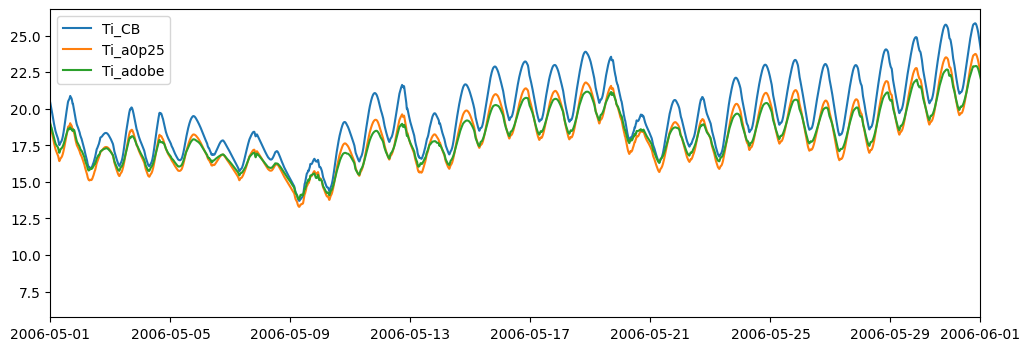

In [75]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-05-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(temps.Ti_CB, label="Ti_CB")
ax.plot(temps.Ti_a0p25, label="Ti_a0p25")
ax.plot(temps.Ti_adobe, label="Ti_adobe")

ax.legend()

ax.set_xlim(f1,f2)

In [76]:
f = "../osm/015_orientacion/run/eplusout.sql"
orientacion = read_sql(f,alias=True)
data_orientacion = orientacion.data
data_orientacion

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,To,RECAMARAPA:Zone Air Relative Humidity (%),RECAMARAPA:Zone Air Temperature (C),Ti_RECAMARAPA,RECAMARAPB:Zone Air Relative Humidity (%),RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,14.938409,NaN,NaN,20.806899,NaN,NaN,17.374562,NaN,...,NaN,NaN,NaN,15.336217,NaN,NaN,16.097846,NaN,NaN,16.344782
2006-01-01 00:20:00,NaN,NaN,14.902084,NaN,NaN,20.688271,NaN,NaN,17.322435,NaN,...,NaN,NaN,NaN,15.232501,NaN,NaN,16.023767,NaN,NaN,16.241854
2006-01-01 00:30:00,NaN,NaN,14.866480,NaN,NaN,20.570470,NaN,NaN,17.270301,NaN,...,NaN,NaN,NaN,15.129808,NaN,NaN,15.946080,NaN,NaN,16.139594
2006-01-01 00:40:00,NaN,NaN,14.830075,NaN,NaN,20.451441,NaN,NaN,17.216364,NaN,...,NaN,NaN,NaN,15.027291,NaN,NaN,15.869682,NaN,NaN,16.036441
2006-01-01 00:50:00,NaN,NaN,14.793202,NaN,NaN,20.332344,NaN,NaN,17.160695,NaN,...,NaN,NaN,NaN,14.925150,NaN,NaN,15.793930,NaN,NaN,15.932736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,14.837588,NaN,NaN,20.472192,NaN,NaN,17.069359,NaN,...,NaN,NaN,NaN,15.443247,NaN,NaN,15.899899,NaN,NaN,16.391752
2006-12-31 23:30:00,NaN,NaN,14.812563,NaN,NaN,20.373933,NaN,NaN,17.036000,NaN,...,NaN,NaN,NaN,15.359546,NaN,NaN,15.851247,NaN,NaN,16.311770
2006-12-31 23:40:00,NaN,NaN,14.787651,NaN,NaN,20.273161,NaN,NaN,17.001148,NaN,...,NaN,NaN,NaN,15.274967,NaN,NaN,15.800484,NaN,NaN,16.230547


In [77]:
temps["Ti_orientacion"] = sum(data_orientacion[f"Ti_{zona}"] * peso for zona, peso in pesos.items())
temps

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,RECAMARAPB:Zone Air Relative Humidity (%),RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA,Ti_CB,Ti_a0p25,Ti_adobe,Ti_orientacion
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,15.875336,NaN,NaN,18.341211,NaN,NaN,20.391096,NaN,...,NaN,NaN,15.060757,NaN,NaN,17.498457,16.866821,14.723733,14.626421,16.302907
2006-01-01 00:20:00,NaN,NaN,15.834611,NaN,NaN,18.265357,NaN,NaN,20.303718,NaN,...,NaN,NaN,14.997618,NaN,NaN,17.392559,16.781090,14.653233,14.575291,16.219610
2006-01-01 00:30:00,NaN,NaN,15.792917,NaN,NaN,18.191310,NaN,NaN,20.215694,NaN,...,NaN,NaN,14.932578,NaN,NaN,17.286770,16.694578,14.582641,14.523813,16.136210
2006-01-01 00:40:00,NaN,NaN,15.749197,NaN,NaN,18.119315,NaN,NaN,20.125153,NaN,...,NaN,NaN,14.863191,NaN,NaN,17.179488,16.607128,14.510939,14.471190,16.052380
2006-01-01 00:50:00,NaN,NaN,15.702778,NaN,NaN,18.047369,NaN,NaN,20.034640,NaN,...,NaN,NaN,14.788735,NaN,NaN,17.071413,16.518970,14.438225,14.417641,15.968251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,15.600781,NaN,NaN,17.975080,NaN,NaN,20.117233,NaN,...,NaN,NaN,14.895479,NaN,NaN,17.493418,16.763921,14.858670,14.718538,16.233398
2006-12-31 23:30:00,NaN,NaN,15.575942,NaN,NaN,17.924359,NaN,NaN,20.040253,NaN,...,NaN,NaN,14.855624,NaN,NaN,17.410702,16.700208,14.808625,14.683317,16.170783
2006-12-31 23:40:00,NaN,NaN,15.549530,NaN,NaN,17.872016,NaN,NaN,19.963115,NaN,...,NaN,NaN,14.814164,NaN,NaN,17.326870,16.635332,14.756996,14.646629,16.106937


(np.float64(13269.0), np.float64(13300.0))

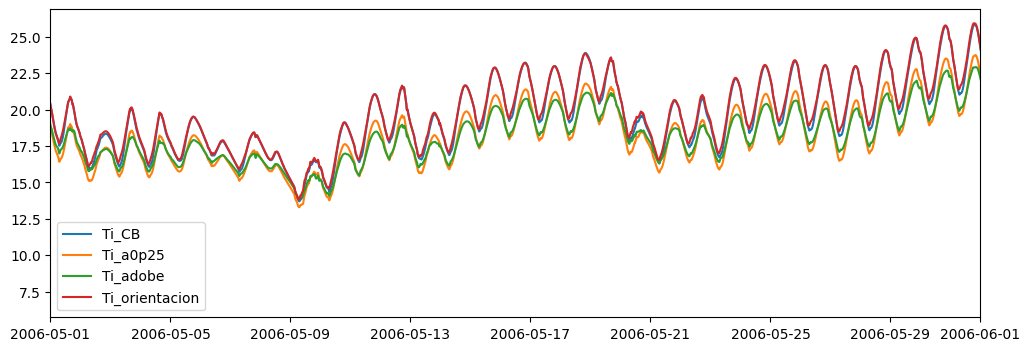

In [78]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-05-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(temps.Ti_CB, label="Ti_CB")
ax.plot(temps.Ti_a0p25, label="Ti_a0p25")
ax.plot(temps.Ti_adobe, label="Ti_adobe")
ax.plot(temps.Ti_orientacion, label="Ti_orientacion")

ax.legend()

ax.set_xlim(f1,f2)

In [79]:
f = "../osm/018_protecciones/run/eplusout.sql"
protecciones = read_sql(f,alias=True)
data_protecciones = protecciones.data
data_protecciones

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,To,RECAMARAPA:Zone Air Relative Humidity (%),RECAMARAPA:Zone Air Temperature (C),Ti_RECAMARAPA,RECAMARAPB:Zone Air Relative Humidity (%),RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,15.579935,NaN,NaN,18.153192,NaN,NaN,19.952793,NaN,...,8.566667,NaN,NaN,14.994942,NaN,NaN,14.878513,NaN,NaN,17.217902
2006-01-01 00:20:00,NaN,NaN,15.544196,NaN,NaN,18.077455,NaN,NaN,19.871085,NaN,...,8.333333,NaN,NaN,14.893195,NaN,NaN,14.817011,NaN,NaN,17.116420
2006-01-01 00:30:00,NaN,NaN,15.507025,NaN,NaN,18.003466,NaN,NaN,19.790269,NaN,...,8.100000,NaN,NaN,14.790164,NaN,NaN,14.752981,NaN,NaN,17.014748
2006-01-01 00:40:00,NaN,NaN,15.466134,NaN,NaN,17.931447,NaN,NaN,19.708055,NaN,...,7.866667,NaN,NaN,14.686552,NaN,NaN,14.683453,NaN,NaN,16.911465
2006-01-01 00:50:00,NaN,NaN,15.424474,NaN,NaN,17.859465,NaN,NaN,19.625346,NaN,...,7.633333,NaN,NaN,14.584891,NaN,NaN,14.611970,NaN,NaN,16.807314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,15.282779,NaN,NaN,17.809966,NaN,NaN,19.675091,NaN,...,10.366667,NaN,NaN,15.086100,NaN,NaN,14.705756,NaN,NaN,17.213503
2006-12-31 23:30:00,NaN,NaN,15.262637,NaN,NaN,17.758998,NaN,NaN,19.606177,NaN,...,10.300000,NaN,NaN,15.012389,NaN,NaN,14.667939,NaN,NaN,17.134959
2006-12-31 23:40:00,NaN,NaN,15.240715,NaN,NaN,17.706408,NaN,NaN,19.537368,NaN,...,10.233333,NaN,NaN,14.937726,NaN,NaN,14.628057,NaN,NaN,17.055232


In [80]:
temps["Ti_protecciones"] = sum(data_protecciones[f"Ti_{zona}"] * peso for zona, peso in pesos.items())
temps

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA,Ti_CB,Ti_a0p25,Ti_adobe,Ti_orientacion,Ti_protecciones
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,15.875336,NaN,NaN,18.341211,NaN,NaN,20.391096,NaN,...,NaN,15.060757,NaN,NaN,17.498457,16.866821,14.723733,14.626421,16.302907,16.655633
2006-01-01 00:20:00,NaN,NaN,15.834611,NaN,NaN,18.265357,NaN,NaN,20.303718,NaN,...,NaN,14.997618,NaN,NaN,17.392559,16.781090,14.653233,14.575291,16.219610,16.572624
2006-01-01 00:30:00,NaN,NaN,15.792917,NaN,NaN,18.191310,NaN,NaN,20.215694,NaN,...,NaN,14.932578,NaN,NaN,17.286770,16.694578,14.582641,14.523813,16.136210,16.489064
2006-01-01 00:40:00,NaN,NaN,15.749197,NaN,NaN,18.119315,NaN,NaN,20.125153,NaN,...,NaN,14.863191,NaN,NaN,17.179488,16.607128,14.510939,14.471190,16.052380,16.403657
2006-01-01 00:50:00,NaN,NaN,15.702778,NaN,NaN,18.047369,NaN,NaN,20.034640,NaN,...,NaN,14.788735,NaN,NaN,17.071413,16.518970,14.438225,14.417641,15.968251,16.317956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,15.600781,NaN,NaN,17.975080,NaN,NaN,20.117233,NaN,...,NaN,14.895479,NaN,NaN,17.493418,16.763921,14.858670,14.718538,16.233398,16.549378
2006-12-31 23:30:00,NaN,NaN,15.575942,NaN,NaN,17.924359,NaN,NaN,20.040253,NaN,...,NaN,14.855624,NaN,NaN,17.410702,16.700208,14.808625,14.683317,16.170783,16.488517
2006-12-31 23:40:00,NaN,NaN,15.549530,NaN,NaN,17.872016,NaN,NaN,19.963115,NaN,...,NaN,14.814164,NaN,NaN,17.326870,16.635332,14.756996,14.646629,16.106937,16.426483


(np.float64(13269.0), np.float64(13300.0))

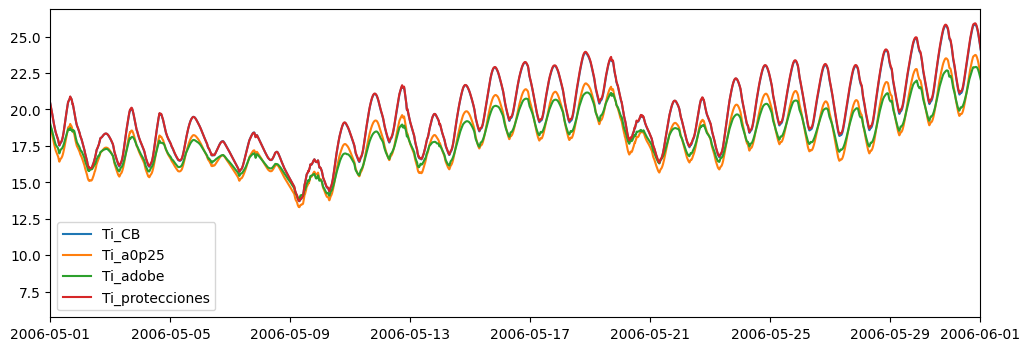

In [81]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-05-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(temps.Ti_CB, label="Ti_CB")
ax.plot(temps.Ti_a0p25, label="Ti_a0p25")
ax.plot(temps.Ti_adobe, label="Ti_adobe")
ax.plot(temps.Ti_protecciones, label="Ti_protecciones")

ax.legend()

ax.set_xlim(f1,f2)

In [82]:
f = "../osm/019_ventilacion_nocturna/run/eplusout.sql"
ventilacion_nocturna = read_sql(f,alias=True)
data_ventilacion_nocturna = ventilacion_nocturna.data
data_ventilacion_nocturna

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,To,RECAMARAPA:Zone Air Relative Humidity (%),RECAMARAPA:Zone Air Temperature (C),Ti_RECAMARAPA,RECAMARAPB:Zone Air Relative Humidity (%),RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,13.845985,NaN,NaN,15.936574,NaN,NaN,16.585398,NaN,...,8.566667,NaN,NaN,12.983141,NaN,NaN,12.885656,NaN,NaN,14.686481
2006-01-01 00:20:00,NaN,NaN,13.769343,NaN,NaN,15.834476,NaN,NaN,16.467548,NaN,...,8.333333,NaN,NaN,12.859079,NaN,NaN,12.785603,NaN,NaN,14.551335
2006-01-01 00:30:00,NaN,NaN,13.690191,NaN,NaN,15.731178,NaN,NaN,16.347104,NaN,...,8.100000,NaN,NaN,12.734287,NaN,NaN,12.684553,NaN,NaN,14.414903
2006-01-01 00:40:00,NaN,NaN,13.608802,NaN,NaN,15.627456,NaN,NaN,16.223196,NaN,...,7.866667,NaN,NaN,12.606299,NaN,NaN,12.580393,NaN,NaN,14.275080
2006-01-01 00:50:00,NaN,NaN,13.527445,NaN,NaN,15.523601,NaN,NaN,16.099225,NaN,...,7.633333,NaN,NaN,12.477578,NaN,NaN,12.475618,NaN,NaN,14.134673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,13.970489,NaN,NaN,15.985214,NaN,NaN,16.813700,NaN,...,10.366667,NaN,NaN,13.421742,NaN,NaN,13.205333,NaN,NaN,15.085344
2006-12-31 23:30:00,NaN,NaN,13.934792,NaN,NaN,15.927046,NaN,NaN,16.741017,NaN,...,10.300000,NaN,NaN,13.359597,NaN,NaN,13.161817,NaN,NaN,15.009296
2006-12-31 23:40:00,NaN,NaN,13.894231,NaN,NaN,15.865440,NaN,NaN,16.663202,NaN,...,10.233333,NaN,NaN,13.290980,NaN,NaN,13.111627,NaN,NaN,14.927372


In [83]:
temps["Ti_ventilacion_nocturna"] = sum(data_ventilacion_nocturna[f"Ti_{zona}"] * peso for zona, peso in pesos.items())
temps

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA,Ti_CB,Ti_a0p25,Ti_adobe,Ti_orientacion,Ti_protecciones,Ti_ventilacion_nocturna
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,15.875336,NaN,NaN,18.341211,NaN,NaN,20.391096,NaN,...,15.060757,NaN,NaN,17.498457,16.866821,14.723733,14.626421,16.302907,16.655633,14.268702
2006-01-01 00:20:00,NaN,NaN,15.834611,NaN,NaN,18.265357,NaN,NaN,20.303718,NaN,...,14.997618,NaN,NaN,17.392559,16.781090,14.653233,14.575291,16.219610,16.572624,14.153082
2006-01-01 00:30:00,NaN,NaN,15.792917,NaN,NaN,18.191310,NaN,NaN,20.215694,NaN,...,14.932578,NaN,NaN,17.286770,16.694578,14.582641,14.523813,16.136210,16.489064,14.036018
2006-01-01 00:40:00,NaN,NaN,15.749197,NaN,NaN,18.119315,NaN,NaN,20.125153,NaN,...,14.863191,NaN,NaN,17.179488,16.607128,14.510939,14.471190,16.052380,16.403657,13.915889
2006-01-01 00:50:00,NaN,NaN,15.702778,NaN,NaN,18.047369,NaN,NaN,20.034640,NaN,...,14.788735,NaN,NaN,17.071413,16.518970,14.438225,14.417641,15.968251,16.317956,13.795278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,15.600781,NaN,NaN,17.975080,NaN,NaN,20.117233,NaN,...,14.895479,NaN,NaN,17.493418,16.763921,14.858670,14.718538,16.233398,16.549378,14.589240
2006-12-31 23:30:00,NaN,NaN,15.575942,NaN,NaN,17.924359,NaN,NaN,20.040253,NaN,...,14.855624,NaN,NaN,17.410702,16.700208,14.808625,14.683317,16.170783,16.488517,14.528192
2006-12-31 23:40:00,NaN,NaN,15.549530,NaN,NaN,17.872016,NaN,NaN,19.963115,NaN,...,14.814164,NaN,NaN,17.326870,16.635332,14.756996,14.646629,16.106937,16.426483,14.461301


(np.float64(13269.0), np.float64(13300.0))

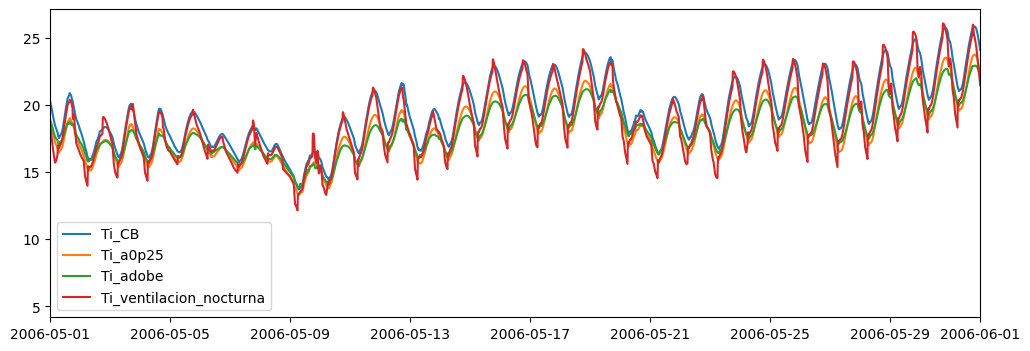

In [84]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-05-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(temps.Ti_CB, label="Ti_CB")
ax.plot(temps.Ti_a0p25, label="Ti_a0p25")
ax.plot(temps.Ti_adobe, label="Ti_adobe")
ax.plot(temps.Ti_ventilacion_nocturna, label="Ti_ventilacion_nocturna")

ax.legend()

ax.set_xlim(f1,f2)

In [85]:
Tma = temps.To["2006-05-01":"2006-05-31"].mean()
Tmin = temps.To["2006-05-01":"2006-05-31"].min()
Tmax = temps.To["2006-05-01":"2006-05-31"].max()

In [86]:
Tn = 13.5 + .54 * Tma
Tn

np.float64(23.599591327144935)

In [87]:
DeltaTa = Tmax - Tmin
DeltaTa

np.float64(23.3)

In [88]:
DeltaTc = 4

In [89]:
from pvlib.iotools import read_epw
f = "../epw/MEX_CMX_Cuidad.Mexico.Central.766800_TMYx.2011-2025.epw"
weather, metadata = read_epw(f)

gdc_base_f = 65
gdr_base_f = 50
gdc_base_c = (gdc_base_f - 32) * 5 / 9
gdr_base_c = (gdr_base_f - 32) * 5 / 9

estadisticas_mensuales = pd.DataFrame({
    'temp_media': weather['temp_air'].groupby(weather.index.month).mean(),
    'temp_min': weather['temp_air'].groupby(weather.index.month).min(),
    'temp_max': weather['temp_air'].groupby(weather.index.month).max(),
})
meses_es = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
estadisticas_mensuales.index = [meses_es[i - 1] for i in estadisticas_mensuales.index]

# Calcular GDC/GDR con CONUEE horas de los dias promedio mensuales y convertir a totales mensuales
monthly_hourly_mean = weather['temp_air'].groupby([weather.index.month, weather.index.hour]).mean().unstack(level=1)
monthly_hourly_mean = monthly_hourly_mean.reindex(columns=range(24))

monthly_conuee_dd = pd.DataFrame({
    'HDD18.3': (18.3 - monthly_hourly_mean).clip(lower=0).sum(axis=1) / 24,
    'CDD10': (monthly_hourly_mean - 10).clip(lower=0).sum(axis=1) / 24,
})

days_in_month = weather['temp_air'].groupby(weather.index.month).size().div(24)
monthly_totals = monthly_conuee_dd.mul(days_in_month.values, axis=0)
monthly_totals.index = [meses_es[m - 1] for m in monthly_totals.index]

estadisticas_mensuales['GDCA18.3'] = monthly_totals['HDD18.3'].values
estadisticas_mensuales['GDRA10'] = monthly_totals['CDD10'].values

In [90]:
from pvlib.iotools import read_epw
import numpy as np
f = "../epw/MEX_CMX_Cuidad.Mexico.Central.766800_TMYx.2011-2025.epw"
weather, metadata = read_epw(f)

gdc_base_f = 65
gdr_base_f = 50
gdc_base_c = (gdc_base_f - 32) * 5 / 9
gdr_base_c = (gdr_base_f - 32) * 5 / 9

estadisticas_mensuales = pd.DataFrame({
    'temp_media': weather['temp_air'].groupby(weather.index.month).mean(),
    'temp_min': weather['temp_air'].groupby(weather.index.month).min(),
    'temp_max': weather['temp_air'].groupby(weather.index.month).max(),
})
meses_es = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
estadisticas_mensuales.index = [meses_es[i - 1] for i in estadisticas_mensuales.index]

estadisticas_mensuales["Tn"] = 13.5 + .54 * estadisticas_mensuales["temp_media"]

estadisticas_mensuales["DeltaTa"] = estadisticas_mensuales["temp_max"] - estadisticas_mensuales["temp_min"]

conditions = [
    estadisticas_mensuales['DeltaTa'] < 16,
    (estadisticas_mensuales['DeltaTa'] >= 16) & (estadisticas_mensuales['DeltaTa'] < 19),
    (estadisticas_mensuales['DeltaTa'] >= 19) & (estadisticas_mensuales['DeltaTa'] < 24),
    estadisticas_mensuales['DeltaTa'] >= 24,
]
choices = [1.5, 3.5 / 2, 2, 4.5 / 2]
estadisticas_mensuales['banda'] = np.select(conditions, choices, default=np.nan)

estadisticas_mensuales["Tn_sup"] = estadisticas_mensuales["Tn"] + estadisticas_mensuales["banda"]
estadisticas_mensuales['Tn_inf'] = estadisticas_mensuales["Tn"] - estadisticas_mensuales["banda"]

# Hourly clipped differences using monthly comfort limits
temp_air = weather['temp_air']
mes_hora = pd.Series(weather.index.month, index=weather.index).map(lambda m: meses_es[m - 1])
tn_inf_h = mes_hora.map(estadisticas_mensuales['Tn_inf'])
tn_sup_h = mes_hora.map(estadisticas_mensuales['Tn_sup'])

dif_temp_tninf_h = (temp_air - tn_inf_h).clip(lower=0)
dif_tnsup_temp_h = (tn_sup_h - temp_air).clip(lower=0)

estadisticas_mensuales['GHDF'] = dif_temp_tninf_h.groupby(mes_hora).sum().reindex(estadisticas_mensuales.index)
estadisticas_mensuales['GHDC'] = dif_tnsup_temp_h.groupby(mes_hora).sum().reindex(estadisticas_mensuales.index)

estadisticas_mensuales

,temp_media,temp_min,temp_max,Tn,DeltaTa,banda,Tn_sup,Tn_inf,GHDF,GHDC
Ene,12.207796,2.4,24.4,20.092210,22.0,2.00,22.092210,18.092210,391.862032,7382.453290
Feb,14.668601,3.7,27.0,21.421045,23.3,2.00,23.421045,19.421045,589.270027,5928.984545
Mar,16.932661,6.5,28.9,22.643637,22.4,2.00,24.643637,20.643637,879.016177,5879.484105
Abr,18.311389,8.1,30.1,23.388150,22.0,2.00,25.388150,21.388150,921.528400,5281.907050
May,18.702823,8.3,31.6,23.599524,23.3,2.00,25.599524,21.599524,864.921806,5289.991202
Jun,17.931389,9.0,28.3,23.182950,19.3,2.00,25.182950,21.182950,515.703100,5287.042400
Jul,17.199597,8.9,26.3,22.787782,17.4,1.75,24.537782,21.037782,256.957097,5474.105484
Ago,16.914785,8.8,25.8,22.633984,17.0,1.75,24.383984,20.883984,187.282097,5559.980097
Sep,16.882222,9.6,26.0,22.616400,16.4,1.75,24.366400,20.866400,265.904800,5395.944800
Oct,15.535081,6.0,28.6,21.888944,22.6,2.00,23.888944,19.888944,402.858960,6289.127315


In [91]:
estadisticas_mensuales["DeltaTa"].min()

np.float64(16.4)

In [92]:
weather['temp_air']

2022-01-01 00:00:00-06:00     7.4
2022-01-01 01:00:00-06:00     6.4
2022-01-01 02:00:00-06:00     5.9
2022-01-01 03:00:00-06:00     4.7
2022-01-01 04:00:00-06:00     4.3
                             ... 
2019-12-31 19:00:00-06:00    14.5
2019-12-31 20:00:00-06:00    12.8
2019-12-31 21:00:00-06:00    12.5
2019-12-31 22:00:00-06:00    10.5
2019-12-31 23:00:00-06:00    10.1
Name: temp_air, Length: 8760, dtype: float64

In [98]:
# Safe normalization: create a one-year hourly index and assign to a copy
tz = weather.index.tz
new_index = pd.date_range(start=pd.Timestamp('2000-01-01', tz=tz), periods=len(weather), freq='h')
weather_one_year = weather.copy()
weather_one_year.index = new_index
# quick checks
print(weather_one_year.index.min(), weather_one_year.index.max(), len(weather_one_year))
print(pd.infer_freq(weather_one_year.index))
print(weather_one_year.index.year.unique())

2000-01-01 00:00:00-06:00 2000-12-30 23:00:00-06:00 8760
h
Index([2000], dtype='int32')


In [100]:
# Map monthly Tn_inf/Tn_sup to the normalized one-year index and compute masks and GHDF/GHDC
mes_hora_one = pd.Series(weather_one_year.index.month, index=weather_one_year.index).map(lambda m: meses_es[m-1])
tn_inf_h_one = mes_hora_one.map(estadisticas_mensuales['Tn_inf'])
tn_sup_h_one = mes_hora_one.map(estadisticas_mensuales['Tn_sup'])

# Boolean masks
confort = (weather_one_year['temp_air'] >= tn_inf_h_one) & (weather_one_year['temp_air'] <= tn_sup_h_one)
calor = weather_one_year['temp_air'] > tn_sup_h_one
frio = weather_one_year['temp_air'] < tn_inf_h_one

# Monthly aggregated GHDF / GHDC based on one-year index
dif_temp_tninf_h_one = (weather_one_year['temp_air'] - tn_inf_h_one).clip(lower=0)
dif_tnsup_temp_h_one = (tn_sup_h_one - weather_one_year['temp_air']).clip(lower=0)

ghdf_one = dif_temp_tninf_h_one.groupby(mes_hora_one).sum().reindex(estadisticas_mensuales.index)
ghdc_one = dif_tnsup_temp_h_one.groupby(mes_hora_one).sum().reindex(estadisticas_mensuales.index)

estadisticas_mensuales['GHDF_one'] = ghdf_one
estadisticas_mensuales['GHDC_one'] = ghdc_one

# Quick checks
print('counts - confort, calor, frio:', confort.sum(), calor.sum(), frio.sum())
estadisticas_mensuales[['GHDF','GHDF_one','GHDC','GHDC_one']]

counts - confort, calor, frio: 1663 579 6518


,GHDF,GHDF_one,GHDC,GHDC_one
Ene,391.862032,391.862032,7382.453290,7382.453290
Feb,589.270027,624.501670,5928.984545,6091.984393
Mar,879.016177,890.441629,5879.484105,5857.340468
Abr,921.528400,905.757300,5281.907050,5311.971500
May,864.921806,890.424661,5289.991202,5236.293581
Jun,515.703100,497.786050,5287.042400,5313.374200
Jul,256.957097,239.546008,5474.105484,5470.481048
Ago,187.282097,192.098113,5559.980097,5566.864081
Sep,265.904800,257.704000,5395.944800,5440.844800
Oct,402.858960,397.258960,6289.127315,6381.916258


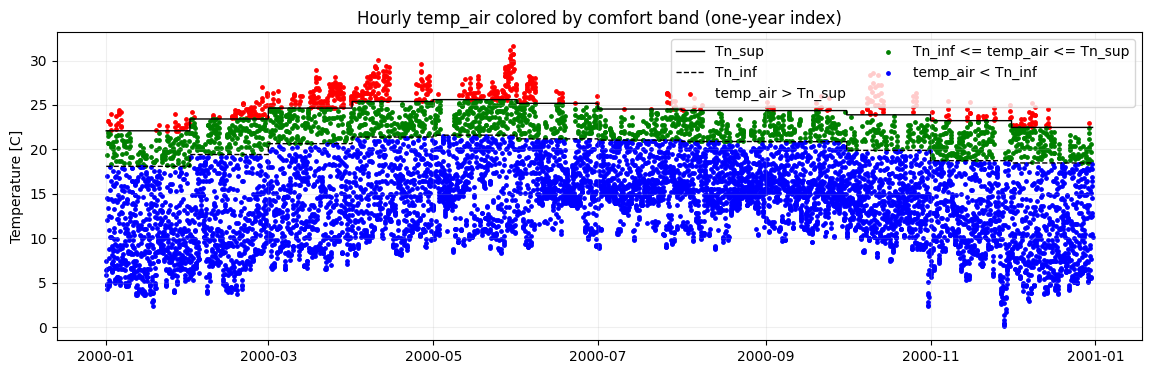

In [101]:
# Plot weather_one_year temp_air colored by comfort bands (uses tn_inf_h_one / tn_sup_h_one)
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(tn_sup_h_one.index, tn_sup_h_one.values, color='black', linewidth=1, label='Tn_sup')
ax.plot(tn_inf_h_one.index, tn_inf_h_one.values, color='black', linewidth=1, linestyle='--', label='Tn_inf')

ax.scatter(weather_one_year.index[calor], weather_one_year['temp_air'][calor], s=6, color='red', label='temp_air > Tn_sup')
ax.scatter(weather_one_year.index[confort], weather_one_year['temp_air'][confort], s=6, color='green', label='Tn_inf <= temp_air <= Tn_sup')
ax.scatter(weather_one_year.index[frio], weather_one_year['temp_air'][frio], s=6, color='blue', label='temp_air < Tn_inf')

ax.set_title('Hourly temp_air colored by comfort band (one-year index)')
ax.set_ylabel('Temperature [C]')
ax.legend(loc='upper right', ncols=2)
ax.grid(alpha=0.2)
plt.show()

In [103]:
from pvlib.iotools import read_epw
import numpy as np
f = "../epw/MEX_CMX_Cuidad.Mexico.Central.766800_TMYx.2011-2025.epw"
weather, metadata = read_epw(f)

gdc_base_f = 65
gdr_base_f = 50
gdc_base_c = (gdc_base_f - 32) * 5 / 9
gdr_base_c = (gdr_base_f - 32) * 5 / 9

# Use monthly mean of daily min/max instead of absolute monthly min/max
daily_extremos = weather['temp_air'].groupby(weather.index.floor('D')).agg(['min', 'max'])
temp_min_mensual = daily_extremos['min'].groupby(daily_extremos.index.month).mean()
temp_max_mensual = daily_extremos['max'].groupby(daily_extremos.index.month).mean()

estadisticas_mensuales = pd.DataFrame({
    'temp_media': weather['temp_air'].groupby(weather.index.month).mean(),
    'temp_min': temp_min_mensual,
    'temp_max': temp_max_mensual,
})
meses_es = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
estadisticas_mensuales.index = [meses_es[i - 1] for i in estadisticas_mensuales.index]

estadisticas_mensuales["Tn"] = 13.5 + .54 * estadisticas_mensuales["temp_media"]

estadisticas_mensuales["DeltaTa"] = estadisticas_mensuales["temp_max"] - estadisticas_mensuales["temp_min"]

conditions = [
    estadisticas_mensuales['DeltaTa'] < 16,
    (estadisticas_mensuales['DeltaTa'] >= 16) & (estadisticas_mensuales['DeltaTa'] < 19),
    (estadisticas_mensuales['DeltaTa'] >= 19) & (estadisticas_mensuales['DeltaTa'] < 24),
    estadisticas_mensuales['DeltaTa'] >= 24,
]
choices = [1.5, 3.5 / 2, 2, 4.5 / 2]
estadisticas_mensuales['banda'] = np.select(conditions, choices, default=np.nan)

estadisticas_mensuales["Tn_sup"] = estadisticas_mensuales["Tn"] + estadisticas_mensuales["banda"]
estadisticas_mensuales['Tn_inf'] = estadisticas_mensuales["Tn"] - estadisticas_mensuales["banda"]

# Hourly clipped differences using monthly comfort limits
temp_air = weather['temp_air']
mes_hora = pd.Series(weather.index.month, index=weather.index).map(lambda m: meses_es[m - 1])
tn_inf_h = mes_hora.map(estadisticas_mensuales['Tn_inf'])
tn_sup_h = mes_hora.map(estadisticas_mensuales['Tn_sup'])

dif_temp_tninf_h = (temp_air - tn_inf_h).clip(lower=0)
dif_tnsup_temp_h = (tn_sup_h - temp_air).clip(lower=0)

estadisticas_mensuales['GHDF'] = dif_temp_tninf_h.groupby(mes_hora).sum().reindex(estadisticas_mensuales.index)
estadisticas_mensuales['GHDC'] = dif_tnsup_temp_h.groupby(mes_hora).sum().reindex(estadisticas_mensuales.index)

estadisticas_mensuales

,temp_media,temp_min,temp_max,Tn,DeltaTa,banda,Tn_sup,Tn_inf,GHDF,GHDC
Ene,12.207796,5.164516,21.380645,20.092210,16.216129,1.75,21.842210,18.342210,352.557500,7205.000032
Feb,14.668601,6.360714,23.332143,21.421045,16.971429,1.75,23.171045,19.671045,539.575250,5777.497830
Mar,16.932661,8.206452,25.670968,22.643637,17.464516,1.75,24.393637,20.893637,816.858911,5721.723185
Abr,18.311389,9.996667,26.730000,23.388150,16.733333,1.75,25.138150,21.638150,857.086200,5131.213700
May,18.702823,10.474194,25.877419,23.599524,15.403226,1.50,25.099524,22.099524,742.114669,4970.301669
Jun,17.931389,11.930000,23.923333,23.182950,11.993333,1.50,24.682950,21.682950,428.381450,4954.281100
Jul,17.199597,11.948387,23.196774,22.787782,11.248387,1.50,24.287782,21.287782,220.773831,5293.291008
Ago,16.914785,11.874194,22.545161,22.633984,10.670968,1.50,24.133984,21.133984,157.595758,5375.878145
Sep,16.882222,11.393333,23.236667,22.616400,11.843333,1.50,24.116400,21.116400,232.151600,5219.729200
Oct,15.535081,9.816129,23.261290,21.888944,13.445161,1.50,23.388944,20.388944,335.737339,5938.260484


2000-01-01 00:00:00-06:00 2000-12-30 23:00:00-06:00 8760
h
Index([2000], dtype='int32')
counts - confort, calor, frio: 1384 703 6673


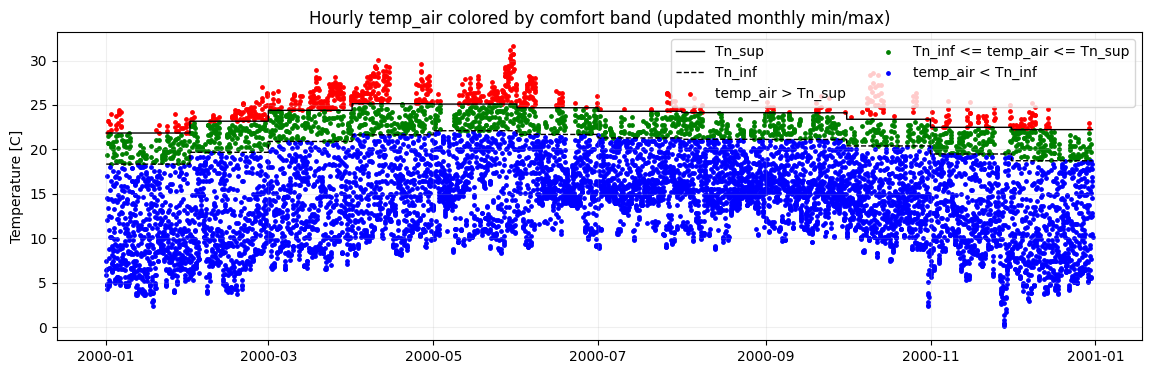

In [105]:
# Safe normalization: create a one-year hourly index and assign to a copy
tz = weather.index.tz
new_index = pd.date_range(start=pd.Timestamp('2000-01-01', tz=tz), periods=len(weather), freq='h')
weather_one_year = weather.copy()
weather_one_year.index = new_index
# quick checks
print(weather_one_year.index.min(), weather_one_year.index.max(), len(weather_one_year))
print(pd.infer_freq(weather_one_year.index))
print(weather_one_year.index.year.unique())

# Map monthly Tn_inf/Tn_sup to the normalized one-year index and compute masks and GHDF/GHDC
mes_hora_one = pd.Series(weather_one_year.index.month, index=weather_one_year.index).map(lambda m: meses_es[m-1])
tn_inf_h_one = mes_hora_one.map(estadisticas_mensuales['Tn_inf'])
tn_sup_h_one = mes_hora_one.map(estadisticas_mensuales['Tn_sup'])

# Boolean masks
confort = (weather_one_year['temp_air'] >= tn_inf_h_one) & (weather_one_year['temp_air'] <= tn_sup_h_one)
calor = weather_one_year['temp_air'] > tn_sup_h_one
frio = weather_one_year['temp_air'] < tn_inf_h_one

# Monthly aggregated GHDF / GHDC based on one-year index
dif_temp_tninf_h_one = (weather_one_year['temp_air'] - tn_inf_h_one).clip(lower=0)
dif_tnsup_temp_h_one = (tn_sup_h_one - weather_one_year['temp_air']).clip(lower=0)

ghdf_one = dif_temp_tninf_h_one.groupby(mes_hora_one).sum().reindex(estadisticas_mensuales.index)
ghdc_one = dif_tnsup_temp_h_one.groupby(mes_hora_one).sum().reindex(estadisticas_mensuales.index)

estadisticas_mensuales['GHDF_one'] = ghdf_one
estadisticas_mensuales['GHDC_one'] = ghdc_one

# Quick checks
print('counts - confort, calor, frio:', confort.sum(), calor.sum(), frio.sum())
estadisticas_mensuales[['GHDF','GHDF_one','GHDC','GHDC_one']]


# Plot using bounds derived from the updated monthly mean daily min/max in estadisticas_mensuales
mes_hora_one = pd.Series(weather_one_year.index.month, index=weather_one_year.index).map(lambda m: meses_es[m - 1])
tn_inf_h_one = mes_hora_one.map(estadisticas_mensuales['Tn_inf'])
tn_sup_h_one = mes_hora_one.map(estadisticas_mensuales['Tn_sup'])

confort = (weather_one_year['temp_air'] >= tn_inf_h_one) & (weather_one_year['temp_air'] <= tn_sup_h_one)
calor = weather_one_year['temp_air'] > tn_sup_h_one
frio = weather_one_year['temp_air'] < tn_inf_h_one

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(tn_sup_h_one.index, tn_sup_h_one.values, color='black', linewidth=1, label='Tn_sup')
ax.plot(tn_inf_h_one.index, tn_inf_h_one.values, color='black', linewidth=1, linestyle='--', label='Tn_inf')

ax.scatter(weather_one_year.index[calor], weather_one_year['temp_air'][calor], s=6, color='red', label='temp_air > Tn_sup')
ax.scatter(weather_one_year.index[confort], weather_one_year['temp_air'][confort], s=6, color='green', label='Tn_inf <= temp_air <= Tn_sup')
ax.scatter(weather_one_year.index[frio], weather_one_year['temp_air'][frio], s=6, color='blue', label='temp_air < Tn_inf')

ax.set_title('Hourly temp_air colored by comfort band (updated monthly min/max)')
ax.set_ylabel('Temperature [C]')
ax.legend(loc='upper right', ncols=2)
ax.grid(alpha=0.2)
plt.show()